# Retrieve and Segment — Colab VOC + CLIP eval

Chạy eval **đầy đủ theo paper** trên Google Colab GPU:

- Backbone: CLIP / MaskCLIP (`configs/clip.yaml`)
- Dataset: PASCAL VOC2012 → mIoU trên val set

**Trước khi chạy:** Runtime → Change runtime type → **GPU** (T4 trở lên).

Paper: https://arxiv.org/abs/2602.23339 · Code: https://github.com/TilemahosAravanis/Retrieve-and-Segment

## 0. Cấu hình nguồn code

- `clone` — clone repo chính thức từ GitHub (mặc định)
- `drive` — dùng thư mục đã upload / sync lên Google Drive

In [ ]:
# === USER SETTINGS ===
SOURCE_MODE = "clone"  # "clone" | "drive"
REPO_URL = "https://github.com/TilemahosAravanis/Retrieve-and-Segment.git"
DRIVE_REPO_DIR = "/content/drive/MyDrive/Retrieve-and-Segment-Demo"  # nếu SOURCE_MODE="drive"

# Smoke: epochs thấp để kiểm tra pipeline. Full paper: 700
SMOKE_EPOCHS = 50
FULL_EPOCHS = 700
SUPPORT_SEED = 100  # paper VOC seeds: 100 18 42 84 92 256 512 1024

import os
from pathlib import Path

if SOURCE_MODE == "drive":
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_ROOT = Path(DRIVE_REPO_DIR)
    assert (REPO_ROOT / "main_eval.py").exists(), f"Không thấy main_eval.py tại {REPO_ROOT}"
else:
    REPO_ROOT = Path("/content/Retrieve-and-Segment")
    if not (REPO_ROOT / "main_eval.py").exists():
        !git clone --depth 1 {REPO_URL} {REPO_ROOT}
    else:
        print("Repo đã có:", REPO_ROOT)

os.chdir(REPO_ROOT)
print("CWD =", Path.cwd())
print("main_eval.py =", (Path.cwd() / "main_eval.py").exists())

Cloning into '/content/Retrieve-and-Segment'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (365/365), done.
remote: Compressing objects: 100% (319/319), done.
remote: Total 365 (delta 26), reused 358 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (365/365), 662.58 KiB | 9.46 MiB/s, done.
Resolving deltas: 100% (26/26), done.
CWD = /content/Retrieve-and-Segment
main_eval.py = True


## 1. Kiểm tra GPU

In [ ]:
import subprocess

!nvidia-smi

smi = subprocess.getoutput("nvidia-smi")
if "CUDA Version:" in smi:
    print("Driver CUDA Version:", smi.split("CUDA Version:")[-1].split()[0])
else:
    print("CẢNH BÁO: không thấy GPU. Runtime → Change runtime type → GPU, rồi Restart runtime.")

Thu Jul 16 13:44:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Cài PyTorch (CUDA) + FAISS + requirements

Pin theo CUDA runtime Colab (thường cu121 / cu124). Không ép `cu128` như README máy local.

In [ ]:
import re
import subprocess
import sys

def cuda_wheel_tag() -> str:
    """Map nvidia-smi CUDA version → PyTorch wheel index tag."""
    out = subprocess.getoutput("nvidia-smi")
    m = re.search(r"CUDA Version:\s*(\d+)\.(\d+)", out)
    if not m:
        return "cu124"  # Colab default fallback
    major, minor = int(m.group(1)), int(m.group(2))
    ver = major * 10 + (minor // 10 if minor >= 10 else minor)
    # Prefer widely available wheels
    if major >= 12 and minor >= 8:
        return "cu128"
    if major >= 12 and minor >= 4:
        return "cu124"
    if major >= 12:
        return "cu121"
    return "cu118"

CUDA_TAG = cuda_wheel_tag()
print("Using PyTorch wheel tag:", CUDA_TAG)

# Install / upgrade torch with CUDA
!pip install -q --upgrade pip
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/{CUDA_TAG}

import torch
print("torch", torch.__version__, "cuda", torch.cuda.is_available(), torch.version.cuda)
assert torch.cuda.is_available(), "Bật Runtime → GPU rồi Restart runtime, chạy lại từ đầu."

Using PyTorch wheel tag: cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.9 MB/s eta 0:00:00
torch 2.11.0+cu128 cuda True 12.8


In [ ]:
# FAISS: thử GPU trước (cần cho core/rns.py). Nếu fail → faiss-cpu + patch fallback trong repo.
import importlib
import subprocess
import sys

faiss_ok_gpu = False

def try_import_faiss():
    import faiss
    return faiss

# 1) pip faiss-gpu (một số môi trường Colab vẫn dùng được)
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "faiss-gpu"])
    faiss = try_import_faiss()
    res = faiss.StandardGpuResources()
    idx = faiss.GpuIndexFlatIP(res, 16)
    del idx, res
    faiss_ok_gpu = True
    print("faiss-gpu OK (pip)")
except Exception as e:
    print("pip faiss-gpu failed:", e)

# 2) conda-forge / pytorch channel (nếu conda có trên runtime)
if not faiss_ok_gpu:
    try:
        subprocess.check_call(
            ["conda", "install", "-y", "-c", "pytorch", "-c", "nvidia", "faiss-gpu=1.8.0"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        importlib.invalidate_caches()
        faiss = try_import_faiss()
        res = faiss.StandardGpuResources()
        idx = faiss.GpuIndexFlatIP(res, 16)
        del idx, res
        faiss_ok_gpu = True
        print("faiss-gpu OK (conda)")
    except Exception as e:
        print("conda faiss-gpu failed:", e)

if not faiss_ok_gpu:
    print("→ Cài faiss-cpu. Repo sẽ fallback IndexFlatIP (CPU) với warning rõ ràng.")
    !pip install -q faiss-cpu
    import faiss
    print("faiss", getattr(faiss, "__version__", "?"), "GPU resources:", hasattr(faiss, "StandardGpuResources"))
else:
    import faiss
    print("faiss GPU ready", getattr(faiss, "__version__", "?"))

faiss-gpu OK (pip)
faiss GPU ready 1.14.3


In [ ]:
!pip install -q -r requirements.txt
print("requirements installed")

requirements installed


In [ ]:
print('Installing missing dependency: addict')
!pip install -q addict
print('addict installed.')

Installing missing dependency: addict
addict installed.


## 3. (Tuỳ chọn) Patch FAISS fallback nếu repo upstream chưa có

Cell này đảm bảo `retrieve_similar_feats` không crash khi chỉ có `faiss-cpu`.

In [ ]:
from pathlib import Path

RNS_PATH = Path("core/rns.py")
text = RNS_PATH.read_text(encoding="utf-8")

if "Falling back to faiss.IndexFlatIP" not in text:
    old = '''def retrieve_similar_feats(model, query_feats, support_feats, k):
    support_bank = faiss.GpuIndexFlatIP(faiss.StandardGpuResources(), support_feats.shape[1])
    support_bank.add(support_feats.contiguous())

    sims, indices = support_bank.search(query_feats.contiguous(), k)

    del supp'''
    new = '''def retrieve_similar_feats(model, query_feats, support_feats, k):
    """Cosine / IP retrieval via FAISS. Prefers GPU index; falls back to CPU with a warning."""
    dim = support_feats.shape[1]
    feats = support_feats.contiguous()
    queries = query_feats.contiguous()

    support_bank = None
    try:
        support_bank = faiss.GpuIndexFlatIP(faiss.StandardGpuResources(), dim)
        support_bank.add(feats)
    except Exception as e:
        print(
            f"[RNS] FAISS GPU index unavailable ({e}). "
            "Falling back to faiss.IndexFlatIP on CPU (slower, same scores)."
        )
        support_bank = faiss.IndexFlatIP(dim)
        if torch.is_tensor(feats):
            feats_np = feats.detach().float().cpu().numpy()
            queries_np = queries.detach().float().cpu().numpy()
        else:
            feats_np, queries_np = feats, queries
        support_bank.add(feats_np)
        sims = torch.as_tensor(sims, device=query_feats.device, dtype=query_feats.dtype)
        indices = torch.as_tensor(indices, device=query_feats.device, dtype=torch.long)
        return sims, indices

    sims, indices = support_bank.search(queries, k)
    del support_bank
    return sims, indices'''
    if old not in text:
        print("DEBUG: The 'old' string defining 'retrieve_similar_feats' was not found in 'core/rns.py'.")
        print("DEBUG: Please compare the following block (the 'old' string) with the content of 'core/rns.py' for 'retrieve_similar_feats' function. Pay close attention to whitespace (spaces, blank lines) and any comments.")
        print("-" * 20 + " Expected 'old' string " + "-" * 20)
        print(old)
        print("-" * 20 + " End Expected 'old' string " + "-" * 20)

        func_start_idx = text.find("def retrieve_similar_feats")
        if func_start_idx != -1:
            print("\n" + "-" * 20 + " Found in 'core/rns.py' (first 300 chars after def) " + "-" * 20)
            print(text[func_start_idx : func_start_idx + 300])
            print("-" * 20 + " End Found in 'core/rns.py' " + "-" * 20)
        else:
            print("\nDEBUG: 'def retrieve_similar_feats' was not explicitly found in 'core/rns.py'.")

        raise RuntimeError("Không khớp signature retrieve_similar_feats — kiểm tra core/rns.py thủ công.")
    RNS_PATH.write_text(text.replace(old, new), encoding="utf-8")
    print("Patched core/rns.py with CPU FAISS fallback")
else:
    print("core/rns.py đã có FAISS fallback")

Patched core/rns.py with CPU FAISS fallback


## 4. Tải PASCAL VOC2012

Đường dẫn config: `./data/VOCdevkit/VOC2012`

In [ ]:
from pathlib import Path
import tarfile
import urllib.request

DATA_ROOT = Path("data")
VOC_ROOT = DATA_ROOT / "VOCdevkit" / "VOC2012"
VOC_TAR = DATA_ROOT / "VOCtrainval_11-May-2012.tar"
VOC_URL = "http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"

DATA_ROOT.mkdir(parents=True, exist_ok=True)

needed = [
    VOC_ROOT / "JPEGImages",
    VOC_ROOT / "SegmentationClass",
    VOC_ROOT / "ImageSets" / "Segmentation" / "train.txt",
    VOC_ROOT / "ImageSets" / "Segmentation" / "val.txt",
]

if all(p.exists() for p in needed):
    print("VOC2012 đã sẵn sàng:", VOC_ROOT)
else:
    if not VOC_TAR.exists():
        print("Downloading VOC2012 (~2GB)...")
        urllib.request.urlretrieve(VOC_URL, VOC_TAR)
        print("Download xong:", VOC_TAR, "size_MB=", VOC_TAR.stat().st_size / 1e6)
    print("Extracting...")
    with tarfile.open(VOC_TAR, "r") as tar:
        tar.extractall(DATA_ROOT)
    assert all(p.exists() for p in needed), "Giải nén VOC thiếu file — kiểm tra lại."
    print("OK:", VOC_ROOT)

n_train = len((VOC_ROOT / "ImageSets/Segmentation/train.txt").read_text().strip().splitlines())
n_val = len((VOC_ROOT / "ImageSets/Segmentation/val.txt").read_text().strip().splitlines())
print(f"train split: {n_train} | val split: {n_val}")

Download xong: data/VOCtrainval_11-May-2012.tar size_MB= 1999.63904
Extracting...


/tmp/ipykernel_654/3078563227.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_ROOT)


OK: data/VOCdevkit/VOC2012
train split: 1464 | val split: 1449


## 5. Smoke eval (epochs thấp)

Chạy nhanh để xác nhận pipeline + GPU. mIoU **chưa** phải số paper.

In [ ]:
import os
from pathlib import Path

LOG_DIR = Path("outputs_colab")
LOG_DIR.mkdir(exist_ok=True)
SMOKE_LOG = LOG_DIR / f"smoke_voc_seed{SUPPORT_SEED}_ep{SMOKE_EPOCHS}.log"

# --- Start fix for 'indicesort_bank' typo in core/rns.py ---
RNS_PATH_FIX = Path("core/rns.py")
if RNS_PATH_FIX.exists():
    rns_text = RNS_PATH_FIX.read_text(encoding="utf-8")
    if "indicesort_bank" in rns_text:
        rns_text = rns_text.replace("indicesort_bank", "indices")
        RNS_PATH_FIX.write_text(rns_text, encoding="utf-8")
        print("Đã sửa lỗi đánh máy 'indicesort_bank' trong core/rns.py")
# --- End fix for 'indicesort_bank' typo ---

cmd = (
    f"torchrun --nproc_per_node=1 --nnodes=1 ./main_eval.py clip.yaml "
    f"method.epochs={SMOKE_EPOCHS} "
    f"support.support_seed={SUPPORT_SEED} "
    f"evaluate.task=[voc] "
    f"2>&1 | tee {SMOKE_LOG}"
)
print("Running:\n", cmd)
get_ipython().system(cmd)
print("Log:", SMOKE_LOG.resolve())


Đã sửa lỗi đánh máy 'indicesort_bank' trong core/rns.py
Running:
 torchrun --nproc_per_node=1 --nnodes=1 ./main_eval.py clip.yaml method.epochs=50 support.support_seed=100 evaluate.task=[voc] 2>&1 | tee outputs_colab/smoke_voc_seed100_ep50.log
Loaded 1449 images
### Validation dataset: voc
Creating model:CLIP_OVSS
Loaded 1464 images
1464it [00:09, 149.52it/s]
Class 19: 83 images
Class 13: 68 images
Class 9: 148 images
Class 20: 83 images
Class 11: 82 images
Class 3: 105 images
Class 18: 93 images
Class 15: 442 images
Class 7: 128 images
Class 17: 63 images
Class 10: 64 images
Class 14: 81 images
Class 5: 87 images
Class 8: 131 images
Class 16: 82 images
Class 0: 1460 images
Class 2: 65 images
Class 4: 78 images
Class 6: 78 images
Class 12: 121 images
Class 1: 88 images
16it [00:09,  1.77it/s]
support bank with per-image visual class feats, shape: torch.Size([336, 512])
1449it [09:45,  2.47it/s]
per class results:

+--------------+-------+-------+
|    Class     |  IoU  |  Acc  |
+-----

## 6. Full paper eval (`epochs=700`)

Chạy sau khi smoke OK. Trên T4 có thể mất **nhiều giờ**. Có thể bỏ qua cell này nếu chỉ cần kiểm tra pipeline.

Để lặp seeds VOC như paper: đổi `SUPPORT_SEED` ∈ `{100,18,42,84,92,256,512,1024}` rồi chạy lại, lấy trung bình mIoU.

In [ ]:
RUN_FULL = True  # đặt False để bỏ qua full eval

if RUN_FULL:
    # Ensure addict is available for torchrun
    print('Installing missing dependency: addict for torchrun')
    !pip install -q addict
    print('addict installed for torchrun.')

    FULL_LOG = LOG_DIR / f"full_voc_seed{SUPPORT_SEED}_ep{FULL_EPOCHS}.log"
    cmd = (
        f"torchrun --nproc_per_node=1 --nnodes=1 ./main_eval.py clip.yaml "
        f"method.epochs={FULL_EPOCHS} "
        f"support.support_seed={SUPPORT_SEED} "
        f"evaluate.task=[voc] "
        f"2>&1 | tee {FULL_LOG}"
    )
    print("Running:\n", cmd)
    get_ipython().system(cmd)
    print("Log:", FULL_LOG.resolve())
else:
    print("Skipped full eval (RUN_FULL=False)")

Installing missing dependency: addict for torchrun
addict installed for torchrun.
Running:
 torchrun --nproc_per_node=1 --nnodes=1 ./main_eval.py clip.yaml method.epochs=700 support.support_seed=100 evaluate.task=[voc] 2>&1 | tee outputs_colab/full_voc_seed100_ep700.log
Loaded 1449 images
### Validation dataset: voc
Creating model:CLIP_OVSS
Loaded 1464 images
1464it [00:10, 145.57it/s]
Class 19: 83 images
Class 13: 68 images
Class 9: 148 images
Class 20: 83 images
Class 11: 82 images
Class 3: 105 images
Class 18: 93 images
Class 15: 442 images
Class 7: 128 images
Class 17: 63 images
Class 10: 64 images
Class 14: 81 images
Class 5: 87 images
Class 8: 131 images
Class 16: 82 images
Class 0: 1460 images
Class 2: 65 images
Class 4: 78 images
Class 6: 78 images
Class 12: 121 images
Class 1: 88 images
16it [00:08,  1.89it/s]
support bank with per-image visual class feats, shape: torch.Size([336, 512])
1449it [36:10,  1.50s/it]
per class results:

+--------------+-------+-------+
|    Class  

## 7. Tóm tắt mIoU từ log + (tuỳ chọn) copy sang Drive

In [ ]:
import re
from pathlib import Path

def extract_miou(log_path: Path):
    if not log_path.exists():
        return None
    text = log_path.read_text(encoding="utf-8", errors="ignore")
    # main_eval prints: [voc] mIoU of N test images: xx.xx%
    hits = re.findall(r"\[voc\] mIoU of .*?: ([0-9.]+)%", text)
    finals = re.findall(r"val/voc_miou: ([0-9.]+)", text)
    return {"voc_line": hits[-1] if hits else None, "final": finals[-1] if finals else None}

for name in sorted(Path("outputs_colab").glob("*.log")):
    print(name.name, extract_miou(name))

# Copy logs to Drive (nếu đã mount)
SAVE_TO_DRIVE = False
DRIVE_OUT = Path("/content/drive/MyDrive/RNS_Colab_Outputs")
if SAVE_TO_DRIVE:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    DRIVE_OUT.mkdir(parents=True, exist_ok=True)
    import shutil
    for p in Path("outputs_colab").glob("*"):
        shutil.copy2(p, DRIVE_OUT / p.name)
    print("Copied to", DRIVE_OUT)

full_voc_seed100_ep700.log {'voc_line': '51.88', 'final': '51.88'}
smoke_voc_seed100_ep50.log {'voc_line': '51.06', 'final': '51.06'}


## Ghi chú

| Mục | Giá trị |
|-----|--------|
| Config | `clip.yaml` |
| Task | `voc` |
| Full epochs | 700 |
| Support / class | `images_per_class: 1` |
| k retrieve | 4 |
| VOC seeds (full support) | 100, 18, 42, 84, 92, 256, 512, 1024 |

VRAM: T4 16GB thường đủ cho CLIP ViT-B/16 + slide window 448. Nếu OOM, giảm `test.test_crop_size` / `support.crop_sizes` qua Hydra override.

## 8. Demo Inference


Demo này minh họa khả năng của mô hình để thực hiện phân đoạn hình ảnh, đặc biệt là zero-shot segmentation, dựa trên lời nhắc văn bản. Bạn có thể tải lên hình ảnh của riêng mình và cung cấp một truy vấn văn bản, sau đó notebook sẽ hiển thị đối tượng tương ứng được phân đoạn trong hình ảnh.

Đây là cách nó chứng minh:

*   **Zero-shot Segmentation:** Mô hình có thể phân đoạn các đối tượng mà nó chưa từng thấy trong quá trình huấn luyện, chỉ dựa vào mô tả bằng văn bản.
*   **Hiểu ngữ cảnh:** Bằng cách sử dụng các lời nhắc văn bản, mô hình chứng minh khả năng hiểu ngữ cảnh và xác định các đối tượng cụ thể trong hình ảnh.
*   **Ứng dụng thực tế:** Điều này mở ra khả năng cho các ứng dụng như tìm kiếm hình ảnh nâng cao, chỉnh sửa ảnh dựa trên văn bản và phân tích hình ảnh tự động.

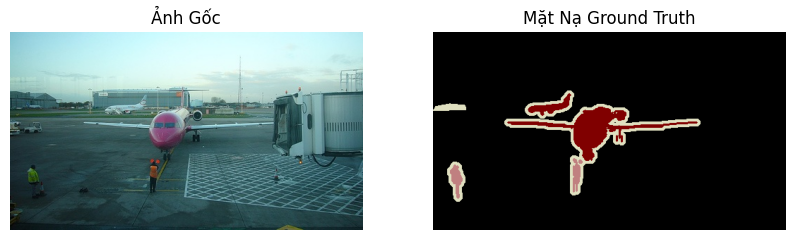

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

VOC_ROOT = "/content/Retrieve-and-Segment/data/VOCdevkit/VOC2012"
IMAGE_ID = "2007_000032" # Changed IMAGE_ID to a valid one with segmentation ground truth

image = Image.open(f"{VOC_ROOT}/JPEGImages/{IMAGE_ID}.jpg")
gt = Image.open(f"{VOC_ROOT}/SegmentationClass/{IMAGE_ID}.png")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Ảnh Gốc") # Translated from "Original Image"
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gt)
plt.title("Mặt Nạ Ground Truth") # Translated from "Ground Truth"
plt.axis("off")

plt.show()